In [1]:
import torch
from base_model import *
from utils import *
from custom_layer import *

In [2]:
torch.backends.mkldnn.enabled = True

In [3]:
train_dataset, val_dataset = get_dataset()
criterion = torch.nn.CrossEntropyLoss()

In [4]:
block0 = nn.Sequential(
    nn.BatchNorm2d(3),#Not normal to use batchnorm at the beginning of the network, but based on empirical results, it can improve the performance of small model
    nn.Conv2d(3, 30, 3, padding=1, groups=3),
    nn.BatchNorm2d(30),
    nn.PReLU(),

    nn.Conv2d(30, 30, 1),   # pointwise conv
    nn.BatchNorm2d(30),
    nn.PReLU(),

    nn.Conv2d(30, 30, 3, padding=1, groups=30),
    nn.BatchNorm2d(30),
    nn.PReLU(),
    HybridPoolingV0(30),          # 32 → 16

    nn.Conv2d(30, 30, 1),   # pointwise conv
    nn.BatchNorm2d(30),
    nn.PReLU(),
)
block1 = nn.Sequential(
    # -------- Block 2 --------
    nn.Conv2d(30, 60, 3, padding=1,groups=30),
    nn.BatchNorm2d(60),
    nn.PReLU(),

    nn.Conv2d(60, 60, 1),   # pointwise conv
    nn.BatchNorm2d(60),
    nn.PReLU(),

    nn.Conv2d(60, 60, 3, padding=1,groups=60),
    nn.BatchNorm2d(60),
    nn.PReLU(),
    HybridPoolingV0(60),          # 16 → 8

    nn.Conv2d(60, 60, 1),   # pointwise conv
    nn.BatchNorm2d(60),
    nn.PReLU(),
)
block2 = nn.Sequential(
    # -------- Block 3 --------
    nn.Conv2d(60, 60, 3, padding=1, groups=60),
    nn.BatchNorm2d(60),
    nn.PReLU(),

    nn.Conv2d(60, 60, 1),   # pointwise conv
    nn.BatchNorm2d(60),
    nn.PReLU(),

    nn.Conv2d(60, 60, 3, padding=1, groups=60),
    nn.BatchNorm2d(60),
    nn.PReLU(),
    HybridPoolingV0(60),          # 8 → 4

    nn.Conv2d(60, 60, 1),   # pointwise conv
    nn.BatchNorm2d(60),
    nn.PReLU(),
)
block3 = nn.Sequential(
    # -------- Block 4 --------
    nn.Conv2d(60, 60, 3, padding=1, groups=60),
    nn.BatchNorm2d(60),
    nn.PReLU(),

    # nn.Conv2d(60, 60, 1),   # pointwise conv
    # nn.BatchNorm2d(60),
    # nn.PReLU(),

    nn.Conv2d(60, 60, 3, padding=1, groups=60),
    nn.BatchNorm2d(60),
    nn.PReLU(),
    HybridPoolingV0(60),          # 4 → 2

    # nn.Conv2d(60, 60, 1),   # pointwise conv
    # nn.BatchNorm2d(60),
    # nn.PReLU(),
)

classifier = nn.Sequential(
    nn.Flatten(),
    nn.Linear(240, 10)
)

In [5]:
model36_0 = BaseModelF32([block0, block1, block2, block3], classifier)
he_initialization(model36_0)
describe(model36_0)

MACs: 4.57 MMac, Params: 24.99 k
Layer (type:depth-idx)                        Output Shape              Param #
BaseModelF32                                  [1, 10]                   --
├─ModuleList: 1-1                             --                        --
│    └─Sequential: 2-1                        [1, 30, 16, 16]           --
│    │    └─BatchNorm2d: 3-1                  [1, 3, 32, 32]            6
│    │    └─Conv2d: 3-2                       [1, 30, 32, 32]           300
│    │    └─BatchNorm2d: 3-3                  [1, 30, 32, 32]           60
│    │    └─PReLU: 3-4                        [1, 30, 32, 32]           1
│    │    └─Conv2d: 3-5                       [1, 30, 32, 32]           930
│    │    └─BatchNorm2d: 3-6                  [1, 30, 32, 32]           60
│    │    └─PReLU: 3-7                        [1, 30, 32, 32]           1
│    │    └─Conv2d: 3-8                       [1, 30, 32, 32]           300
│    │    └─BatchNorm2d: 3-9                  [1, 30, 32, 32] 

Loading checkpoint from model_weights/model36_0.pt
Starting
Epoch 1/60: Train loss = 1.2029, Train accuracy = 0.5911, Test loss = 1.1632, Test accuracy = 0.6073
Epoch 2/60: Train loss = 0.8159, Train accuracy = 0.7092, Test loss = 0.7740, Test accuracy = 0.7269
Epoch 3/60: Train loss = 0.7152, Train accuracy = 0.7520, Test loss = 0.7271, Test accuracy = 0.7543
Epoch 4/60: Train loss = 0.6963, Train accuracy = 0.7566, Test loss = 0.7130, Test accuracy = 0.7515
Epoch 5/60: Train loss = 0.6837, Train accuracy = 0.7667, Test loss = 0.7393, Test accuracy = 0.7637
Epoch 6/60: Train loss = 0.6412, Train accuracy = 0.7743, Test loss = 0.6849, Test accuracy = 0.7688
Epoch 7/60: Train loss = 0.6610, Train accuracy = 0.7741, Test loss = 0.7186, Test accuracy = 0.7626
Epoch 8/60: Train loss = 0.5610, Train accuracy = 0.8057, Test loss = 0.5884, Test accuracy = 0.8015
Epoch 9/60: Train loss = 0.5401, Train accuracy = 0.8133, Test loss = 0.6003, Test accuracy = 0.7985
Epoch 10/60: Train loss = 0.532

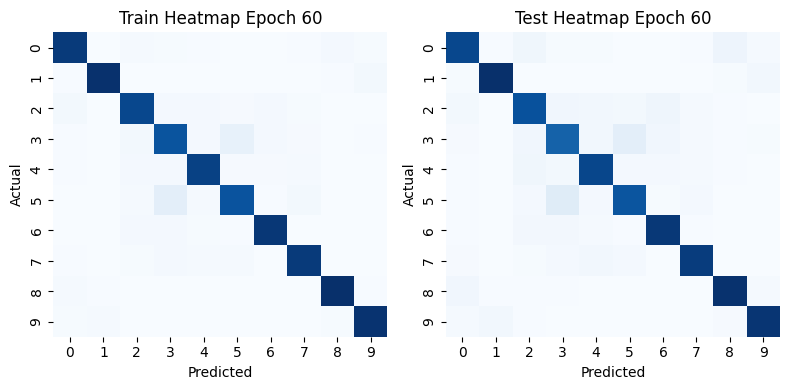

<Figure size 1200x600 with 0 Axes>

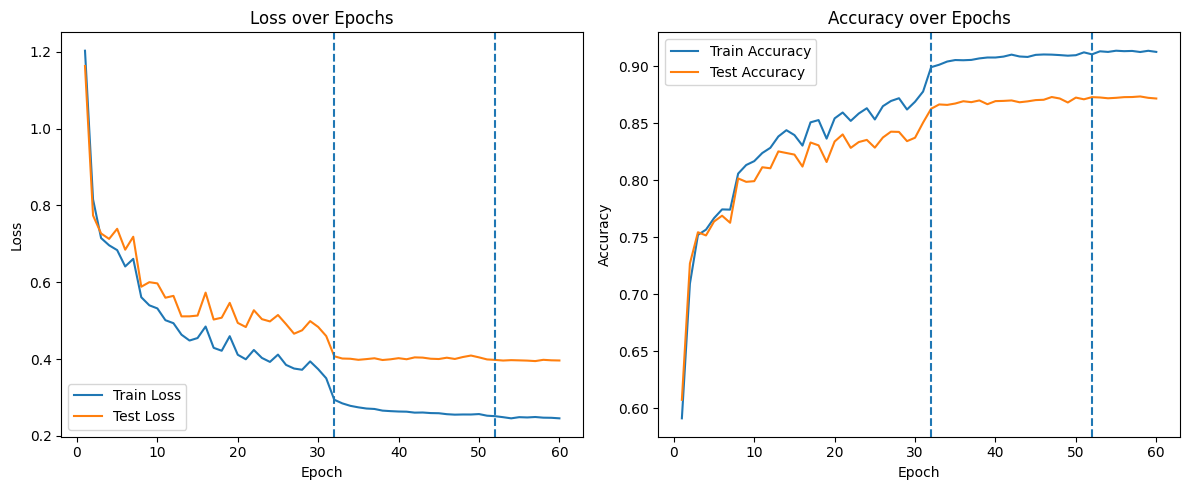

In [6]:
trainf32(model36_0,"model_weights/model36_0.pt",criterion,train_dataset,val_dataset, batch_size=128)

In [7]:
model36_1 = BaseModelF32([block0, block1, block2, block3], classifier)
he_initialization(model36_1)
describe(model36_1)

MACs: 4.57 MMac, Params: 24.99 k
Layer (type:depth-idx)                        Output Shape              Param #
BaseModelF32                                  [1, 10]                   --
├─ModuleList: 1-1                             --                        --
│    └─Sequential: 2-1                        [1, 30, 16, 16]           --
│    │    └─BatchNorm2d: 3-1                  [1, 3, 32, 32]            6
│    │    └─Conv2d: 3-2                       [1, 30, 32, 32]           300
│    │    └─BatchNorm2d: 3-3                  [1, 30, 32, 32]           60
│    │    └─PReLU: 3-4                        [1, 30, 32, 32]           1
│    │    └─Conv2d: 3-5                       [1, 30, 32, 32]           930
│    │    └─BatchNorm2d: 3-6                  [1, 30, 32, 32]           60
│    │    └─PReLU: 3-7                        [1, 30, 32, 32]           1
│    │    └─Conv2d: 3-8                       [1, 30, 32, 32]           300
│    │    └─BatchNorm2d: 3-9                  [1, 30, 32, 32] 

Loading checkpoint from model_weights/model36_1.pt
Starting
Epoch 1/60: Train loss = 1.0407, Train accuracy = 0.6365, Test loss = 0.9786, Test accuracy = 0.6625
Epoch 2/60: Train loss = 0.8232, Train accuracy = 0.7080, Test loss = 0.8040, Test accuracy = 0.7193
Epoch 3/60: Train loss = 0.6682, Train accuracy = 0.7700, Test loss = 0.6754, Test accuracy = 0.7693
Epoch 4/60: Train loss = 0.6324, Train accuracy = 0.7810, Test loss = 0.6390, Test accuracy = 0.7822
Epoch 5/60: Train loss = 0.5978, Train accuracy = 0.7924, Test loss = 0.6074, Test accuracy = 0.7952
Epoch 6/60: Train loss = 0.6034, Train accuracy = 0.7876, Test loss = 0.6088, Test accuracy = 0.7878
Epoch 7/60: Train loss = 0.5677, Train accuracy = 0.8058, Test loss = 0.6129, Test accuracy = 0.8005
Epoch 8/60: Train loss = 0.5440, Train accuracy = 0.8129, Test loss = 0.5862, Test accuracy = 0.8022
Epoch 9/60: Train loss = 0.4974, Train accuracy = 0.8269, Test loss = 0.5449, Test accuracy = 0.8134
Epoch 10/60: Train loss = 0.497

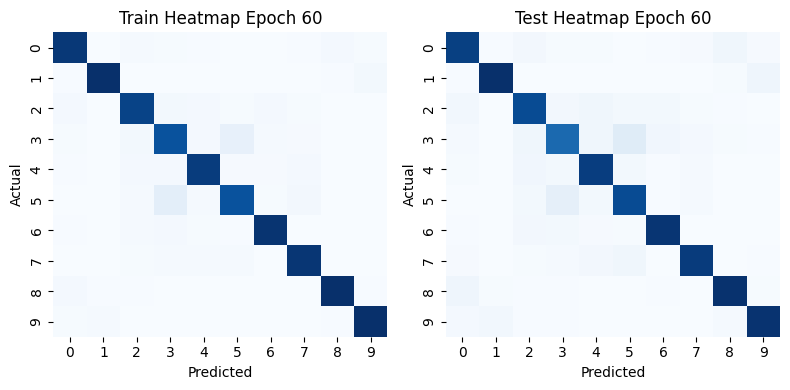

<Figure size 1200x600 with 0 Axes>

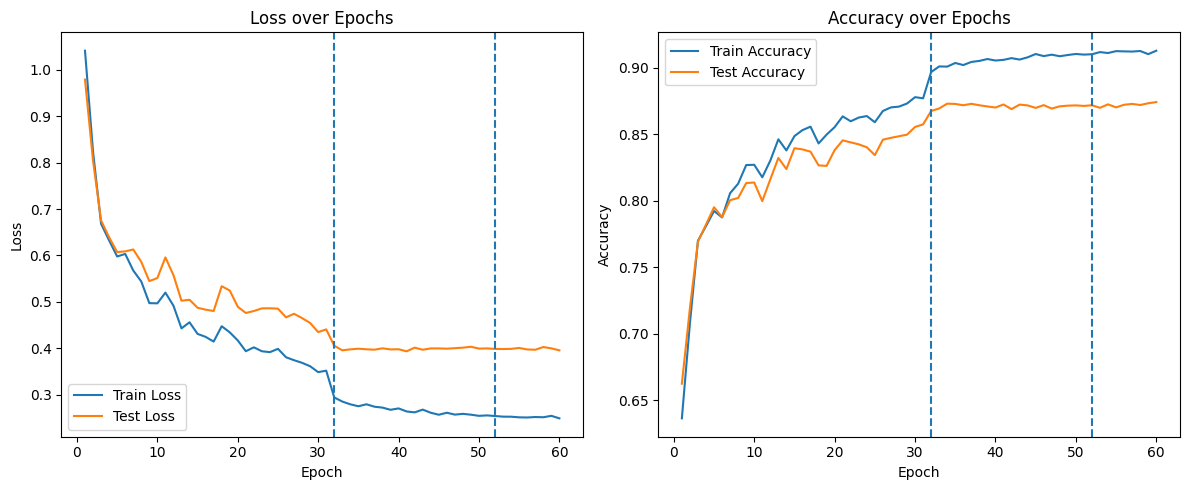

In [8]:
trainf32(model36_1,"model_weights/model36_1.pt",criterion,train_dataset,val_dataset, batch_size=64)